# SMILES enumeration, vectorization and batch generation

[![Smiles Enumeration Header](https://www.wildcardconsulting.dk/wp-content/uploads/2017/03/Smiles_Enumeration_girl_600px.png)](https://www.wildcardconsulting.dk/useful-information/smiles-enumeration-as-data-augmentation-for-molecular-neural-networks/)

SMILES enumeration is the process of writing out all possible SMILES forms of a molecule. It's a useful technique for data augmentation before sequence based modeling of molecules. You can read more about the background in this [blog post](https://www.wildcardconsulting.dk/useful-information/smiles-enumeration-as-data-augmentation-for-molecular-neural-networks/) or [this preprint on arxiv.org](https://arxiv.org/abs/1703.07076)

Import the SmilesEnumerator and instantiate the object

In [2]:
from __future__ import print_function
from SmilesEnumerator import SmilesEnumerator
sme = SmilesEnumerator()
print (help(SmilesEnumerator))

Help on class SmilesEnumerator in module SmilesEnumerator:

class SmilesEnumerator(builtins.object)
 |  SmilesEnumerator(charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True, canonical=False)
 |  
 |  SMILES Enumerator, vectorizer and devectorizer
 |  
 |  #Arguments
 |      charset: string containing the characters for the vectorization
 |        can also be generated via the .fit() method
 |      pad: Length of the vectorization
 |      leftpad: Add spaces to the left of the SMILES
 |      isomericSmiles: Generate SMILES containing information about stereogenic centers
 |      enum: Enumerate the SMILES during transform
 |      canonical: use canonical SMILES during transform (overrides enum)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, charset='@C)(=cOn1S2/H[N]\\', pad=120, leftpad=True, isomericSmiles=True, enum=True, canonical=False)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  fit(self, smiles, extra_char

RDKit WARNING: [15:05:57] Enabling RDKit 2019.09.3 jupyter extensions


A few SMILES strings will be enumerated as a demonstration.

In [7]:
for i in range(10):
    print (sme.randomize_smiles("C(C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(F)F)(C(C(C(F)(F)F)(F)F)(F)F)(F)F"))

C(F)(C(F)(F)F)(F)C(F)(C(F)(C(F)(C(F)(C(F)(F)C(F)(S(=O)(O)=O)F)F)F)F)F
FC(C(C(C(C(F)(F)C(F)(F)F)(F)F)(F)F)(F)F)(C(F)(F)C(F)(F)S(O)(=O)=O)F
FC(C(F)(F)C(F)(F)C(F)(F)F)(F)C(C(F)(C(F)(F)C(S(=O)(=O)O)(F)F)F)(F)F
FC(C(F)(F)C(F)(F)C(F)(C(C(C(C(S(=O)(=O)O)(F)F)(F)F)(F)F)(F)F)F)(F)F
FC(F)(S(=O)(=O)O)C(F)(C(F)(F)C(F)(C(F)(C(C(F)(F)C(F)(F)F)(F)F)F)F)F
FC(C(F)(F)C(F)(C(F)(F)C(F)(F)C(F)(C(F)(F)F)F)F)(C(S(O)(=O)=O)(F)F)F
FC(F)(C(F)(F)S(O)(=O)=O)C(F)(C(C(C(C(F)(F)C(F)(F)F)(F)F)(F)F)(F)F)F
C(F)(C(C(S(O)(=O)=O)(F)F)(F)F)(C(F)(C(C(F)(F)C(F)(F)C(F)(F)F)(F)F)F)F
C(F)(C(F)(C(C(F)(C(F)(F)C(F)(F)S(=O)(=O)O)F)(F)F)F)(C(F)(C(F)(F)F)F)F
FC(C(F)(S(=O)(O)=O)F)(F)C(C(F)(C(F)(F)C(F)(F)C(C(F)(F)F)(F)F)F)(F)F


## Vectorization

Before vectorization SMILES must be stored as strings in an numpy array. The transform takes numpy arrays or pandas series with the SMILES as strings.

In [16]:
import numpy as np
smiles = np.array(["C(C(C(C(C(F)(F)S(=O)(=O)O)(F)F)(F)F)(F)F)(C(C(C(F)(F)F)(F)F)(F)F)(F)F", "C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O"])
print (smiles.shape)

(2,)


Fit the charset and the padding to the SMILES array, alternatively they can be specified when instantiating the object.

In [17]:
sme.fit(smiles)
print (sme.charset)
print (sme.pad)

F(OCS=)
74


There have been added some extra padding to the maximum lenght observed in the smiles array. The SMILES can be transformed to one-hot encoded vectors and showed with matplotlib.

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [1 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 1]
  [1 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [1 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 1]
  [1 0 0 ... 0 0 0]]]


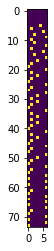

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline
vect = sme.transform(smiles)
print(vect)
plt.imshow(vect[0])

It's a nice piano roll. If the vectorization is repeated, the vectorization will be different due to the enumeration, as sme.enum and sme.canonical is set to True and False, respectively (default settings).

True False


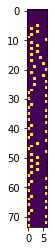

In [19]:
print (sme.enumerate, sme.canonical)
vect = sme.transform(smiles)
plt.imshow(vect[0])

The reverse_transform() function can be used to translate back to a SMILES string, as long as the charset is the same as was used to vectorize.

In [20]:
print (sme.reverse_transform(vect))

['C(C(F)(C(C(S(=O)(=O)O)(F)F)(F)F)F)(F)(F)C(F)(C(C(C(F)(F)F)(F)F)(F)F)F'
 'FC(C(O)=O)(C(C(F)(C(F)(C(C(F)(F)C(F)(F)F)(F)F)F)F)(F)F)F']


## Batch generation for Keras RNN modeling

The SmilesEnumerator class can be used together with the SmilesIterator batch generator for on the fly vectorization for RNN modeling of molecules. Below it's briefly demonstrated how this can be done.

In [21]:
import pandas as pd

data = pd.read_csv("Example_data/Sutherland_DHFR.csv")
print(data.head())

   Unnamed: 0                                      smiles_parent PC_uM_sign  \
0           0                      CCc1nc(N)nc(N)c1-c1ccc(Cl)cc1        NaN   
1           1                  CCc1nc(N)nc(N)c1-c1ccc(Cl)c(Cl)c1        NaN   
2           2                   Cc1nc(N)nc(N)c1-c1ccc(Cl)c(Cl)c1        NaN   
3           3                CCOCc1nc(N)nc(N)c1-c1ccc(Cl)c(Cl)c1        NaN   
4           4  Nc1nc(N)c(-c2ccc(Cl)cc2)c(COc2ccc([N+](=O)[O-]...        NaN   

   PC_uM_value  
0         3.70  
1         1.08  
2         1.68  
3        12.70  
4        85.10  


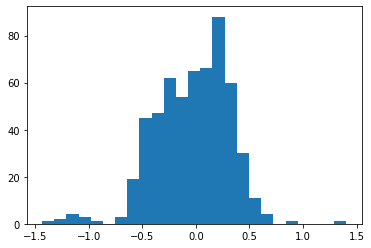

In [23]:
from sklearn.model_selection import train_test_split

#We ignore the > signs, and use random splitting for simplicity
X_train,  X_test, y_train, y_test = train_test_split(data["smiles_parent"],
                                                     np.log(data["PC_uM_value"]).values.reshape(-1,1),
                                                     random_state=42)

from sklearn.preprocessing import RobustScaler
rbs = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(5.0, 95.0), copy=True)
y_train = rbs.fit_transform((y_train))
y_test = rbs.transform(y_test)
_ = plt.hist(y_train, bins=25)

In [38]:
import tensorflow.keras.backend as K
from SmilesEnumerator import SmilesIterator
#The SmilesEnumerator must be fit to the entire dataset, so that all chars are registered
sme.fit(data["smiles_parent"])
sme.leftpad = True
print(sme.charset)
print(sme.pad)
#The dtype is set for the K.floatx(), which is the numerical type configured for Tensorflow or Theano
generator = SmilesIterator(X_train, y_train, sme, batch_size=200, dtype=K.floatx())
## need to change this generator to a sequence in source file

5IBC+]2(=FrNn1oOS[scl4#)H-3
75


In [25]:
X,y = generator.next()
print(X.shape)
print(y.shape)

(200, 75, 27)
(200, 1)


Build a SMILES based RNN QSAR model with Keras.

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.python.keras.utils.data_utils import Sequence

In [37]:
input_shape = X.shape[1:]
output_shape = 1

model = Sequential()
model.add(LSTM(64,
               input_shape=input_shape,
               dropout = 0.19
               #unroll= True
              ))
model.add(Dense(output_shape,
                kernel_regularizer=regularizers.l1_l2(0.005,0.01),
                activation="linear"))

model.compile(loss="mse", optimizer=RMSprop(lr=0.005))
print(model.summary())

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_2 (LSTM)                (None, 64)                23552     
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 65        
Total params: 23,617
Trainable params: 23,617
Non-trainable params: 0
_________________________________________________________________
None


Use the generator object for training.

In [34]:
model.fit_generator(generator, steps_per_epoch=100, epochs=25, workers=4)

AttributeError: 'SmilesIterator' object has no attribute 'shape'

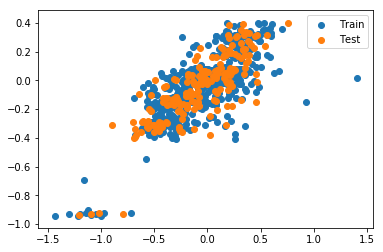

In [133]:
y_pred_train = model.predict(sme.transform(X_train))
y_pred_test = model.predict(sme.transform(X_test))
plt.scatter(y_train, y_pred_train, label="Train")
plt.scatter(y_test, y_pred_test, label="Test")
plt.legend()

Not the best model until now. However, prolonged training with lowering of the learning rate towards the end will improve the model.

In [149]:
#The Enumerator can be used in sampling
i = 1

y_true = y_test[i]
y_pred = model.predict(sme.transform(X_test.iloc[i:i+1]))
print y_true - y_pred

[[-0.38300244]]


0.0616476
[-0.10707214]


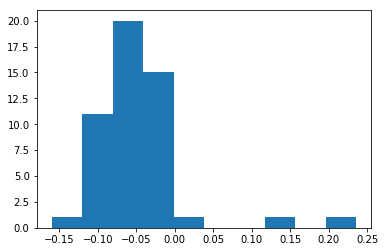

In [151]:
#Enumeration of the SMILES before sampling stabilises the result
smiles_repeat = np.array([X_test.iloc[i:i+1].values[0]]*50)
y_pred = model.predict(sme.transform(smiles_repeat))
print y_pred.std()
print y_true - np.median(y_pred)
_ = plt.hist(y_pred)

## Bibliography

Please cite: [SMILES enumeration as Data Augmentation for Network Modeling of Molecules](https://arxiv.org/abs/1703.07076)

```bibtex
@article{DBLP:journals/corr/Bjerrum17,
  author    = {Esben Jannik Bjerrum},
  title     = {{SMILES} Enumeration as Data Augmentation for Neural Network Modeling
               of Molecules},
  journal   = {CoRR},
  volume    = {abs/1703.07076},
  year      = {2017},
  url       = {http://arxiv.org/abs/1703.07076},
  timestamp = {Wed, 07 Jun 2017 14:40:38 +0200},
  biburl    = {http://dblp.uni-trier.de/rec/bib/journals/corr/Bjerrum17},
  bibsource = {dblp computer science bibliography, http://dblp.org}
}
```


If you find it useful, feel welcome to leave a comment on the [blog.](https://www.wildcardconsulting.dk/useful-information/smiles-enumeration-as-data-augmentation-for-molecular-neural-networks/) 